# M1 OOP measurement model — fit · visualize · synthetic patients

This notebook (1) **loads the certified best fit** — the full-N (9,013), cohort-weighted, transdiagnostic,
**sub-1.05 9-dim Gaussian-copula** map — or optionally re-fits; (2) **visualizes** the map (factor
correlations Φ, loading atlas, patient projections); and (3) generates **synthetic patients** from the
fitted copula model and compares them to the real cohort.

**Best result so far:** the cohort-weighted full-N copula map is the most precise (dev↔suicidality posterior
SD halved vs the balanced-2000 fit), transdiagnostic (each cohort's influence equalized), converged
(max R-hat ≈ 1.02, 0 divergences), and congruent with the earlier maps (Tucker φ ≥ 0.994). One caveat: the
**substance** factor's cross-factor correlations are non-identifiable/unstable — the recommended refinement is
`config.with_substance_orthogonal()` (`--substance-orthogonal`); the loaded weighted fit predates it, so treat
its substance Φ-row as provisional.

Invariants: no imputation (observed-cell likelihoods only); diagnosis is metadata; the copula transform is
invertible, so synthetic patients map back to the original clinical scales.

In [1]:
# Setup: repo root on sys.path + imports
from __future__ import annotations
from dataclasses import replace
from pathlib import Path
import json, os, subprocess, sys

import arviz as az
import numpy as np
import pandas as pd
from IPython.display import Image, display

START = Path.cwd().resolve()
for cand in (START, *START.parents):
    if (cand / "src" / "face" / "models").exists():
        REPO = cand
        break
else:
    raise RuntimeError(f"Could not locate FACE repository root from {START}")
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
# drop any stale `face` import from a different checkout
for m in [n for n in list(sys.modules) if n == "face" or n.startswith("face.")]:
    if getattr(sys.modules[m], "__file__", None) and SRC not in Path(sys.modules[m].__file__).resolve().parents:
        del sys.modules[m]

from face.models.bayesian.measurement_model_oop import (
    MeasurementConfig, MeasurementDataset, StageRunner, PatientProjector, MeasurementVisualizer,
)
from face.models.bayesian.synthetic import (
    export_fitted_model, save_fitted_model, load_fitted_model, generate_synthetic,
)

SEED = 20260605
np.random.seed(SEED)
print("repo:", REPO)

repo: /Users/andriikulakovskyi/Desktop/face-common-bp-sz-dr


## 1. Configure — load the certified best fit, or re-fit

`MODE = "load_certified"` reads the cached **full-N cohort-weighted copula** map from
`results/face/oop_measurement/copula/weighted/` (the best result). `MODE = "refit"` runs a fresh
`--mode medium --likelihood-mode gaussian_copula` fit (cohort-balanced N=2000; the mixed stage is heavy — a
few hours of CPU) and loads from `copula/`.

In [2]:
MODE = "load_certified"        # "load_certified" | "refit"
CONT_STAGE, MIXED_STAGE = "s3_continuous", "s5_9dim_mixed"

base = MeasurementConfig()
if MODE == "load_certified":
    FIT_DIR, FIG_DIR, FULL_N = base.output_dir/"copula"/"weighted", base.figure_dir/"copula"/"weighted", True
elif MODE == "refit":
    FIT_DIR, FIG_DIR, FULL_N = base.output_dir/"copula", base.figure_dir/"copula", False
else:
    raise ValueError(MODE)

config = MeasurementConfig(likelihood_mode="gaussian_copula", output_dir=FIT_DIR, figure_dir=FIG_DIR)
dataset = MeasurementDataset(config)
projector = PatientProjector(config)
visualizer = MeasurementVisualizer(config)
runner = StageRunner(config)
N_SUB = None if FULL_N else 2000
BALANCED = N_SUB is not None
{"mode": MODE, "fit_dir": str(FIT_DIR), "full_n": FULL_N}

{'mode': 'load_certified',
 'fit_dir': '/Users/andriikulakovskyi/Desktop/face-common-bp-sz-dr/results/face/oop_measurement/copula/weighted',
 'full_n': True}

## 2. Load (or fit) the staged map

`load_certified` reads the cached `idata.nc` for the continuous backbone (S3) and the 9-dim mixed map (S5).
`refit` shells out to the tested CLI (`run_measurement_model_oop.py`) so the fit matches the command line
exactly, then loads the same caches.

In [3]:
def _load(stage):
    nc = config.output_dir / stage / "idata.nc"
    return az.from_netcdf(str(nc)) if nc.exists() else None

if MODE == "refit":
    cmd = [sys.executable, str(REPO/"notebooks"/"run_measurement_model_oop.py"),
           "--mode", "medium", "--likelihood-mode", "gaussian_copula", "--no-plots"]
    print("running:", " ".join(cmd), "\n(this is compute-heavy; watch the cell output)")
    subprocess.run(cmd, cwd=REPO, check=True,
                   env={**os.environ, "PYTHONPATH": str(SRC), "HDF5_USE_FILE_LOCKING": "FALSE"})

cont_idata, mixed_idata = _load(CONT_STAGE), _load(MIXED_STAGE)
assert cont_idata is not None and mixed_idata is not None, (
    f"fit not found under {config.output_dir} — run the cohort-weighted fit "
    "(`run_measurement_model_oop.py --likelihood-mode gaussian_copula --cohort-weighted`) or set MODE='refit'.")
manifests = {s: json.loads((config.output_dir/s/"manifest.json").read_text()) for s in (CONT_STAGE, MIXED_STAGE)}
list(manifests)

['s3_continuous', 's5_9dim_mixed']

## 3. Diagnostics

A converged map shows structural R-hat ≲ 1.05 and 0 divergences. The certified weighted full-N copula map is
sub-1.05.

In [4]:
pd.DataFrame([{"stage": s, "N": m.get("N"), "J": m.get("J"),
               "rhat": m["diagnostics"].get("rhat"), "ess": m["diagnostics"].get("ess"),
               "divergences": m["diagnostics"].get("divergences")} for s, m in manifests.items()])

,stage,N,J,rhat,ess,divergences
0,s3_continuous,9013,85,1.01,1815.0,0
1,s5_9dim_mixed,9013,88,1.02,173.0,0


## 4. The 9-dimension factor map

The factor-correlation matrix **Φ** is the transdiagnostic structure: G is orthogonal to every specific
(bifactor), and the biology axes form a block (metabolic↔inflammatory). The **loading atlas** shows which
indicators define each factor.

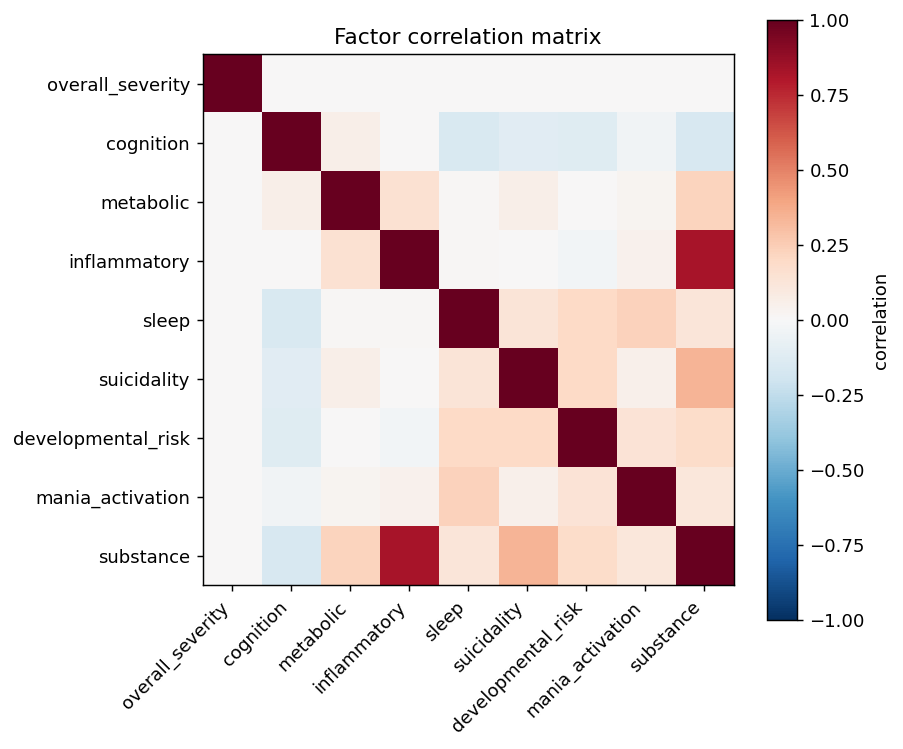

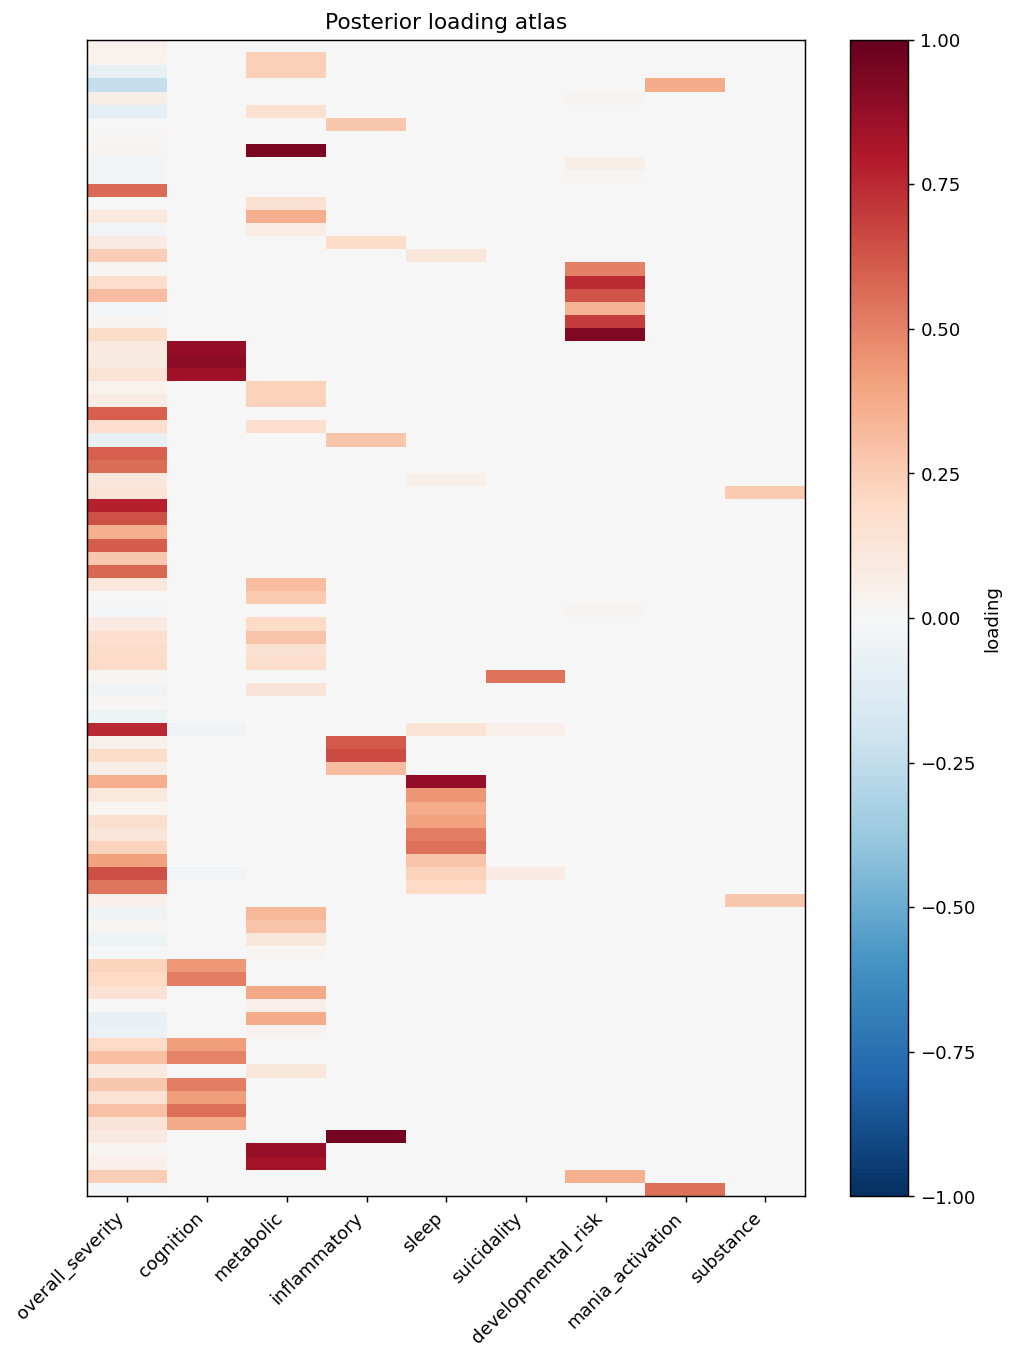

In [5]:
mixed_stage = next(s for s in config.stage_plan if s.name == MIXED_STAGE)
mixed_base = dataset.mixed(
    mixed_stage.factors, explicit_factors=mixed_stage.explicit_factors,
    min_cohorts=mixed_stage.min_cohorts, balanced=True, n_subsample=mixed_stage.n_subsample,
).base
mixed_spec = dataset.loading_spec(
    mixed_base, windows=True,
    bifactor_g_sd={f: 0.05 for f in mixed_stage.explicit_factors if f != "overall_severity"})

phi_path = visualizer.phi_heatmap(mixed_idata.posterior, mixed_base.factor_cols, filename=f"{MIXED_STAGE}_phi.png")
atlas_path = visualizer.loading_atlas(mixed_spec, mixed_idata.posterior, filename=f"{MIXED_STAGE}_loading_atlas.png")
display(Image(str(phi_path))); display(Image(str(atlas_path)))

## 5. Patient projections (position + uncertainty)

Patients are projected onto the continuous backbone with a conditional-Gaussian projection using **only their
observed cells** — each gets a coordinate and a 94% HDI per axis. Reliability tiers reflect how many home
indicators a patient has (well / partial / prior-dominated). The map scatter places biology (metabolic) vs
general severity (G); biology should sit roughly orthogonal to G.

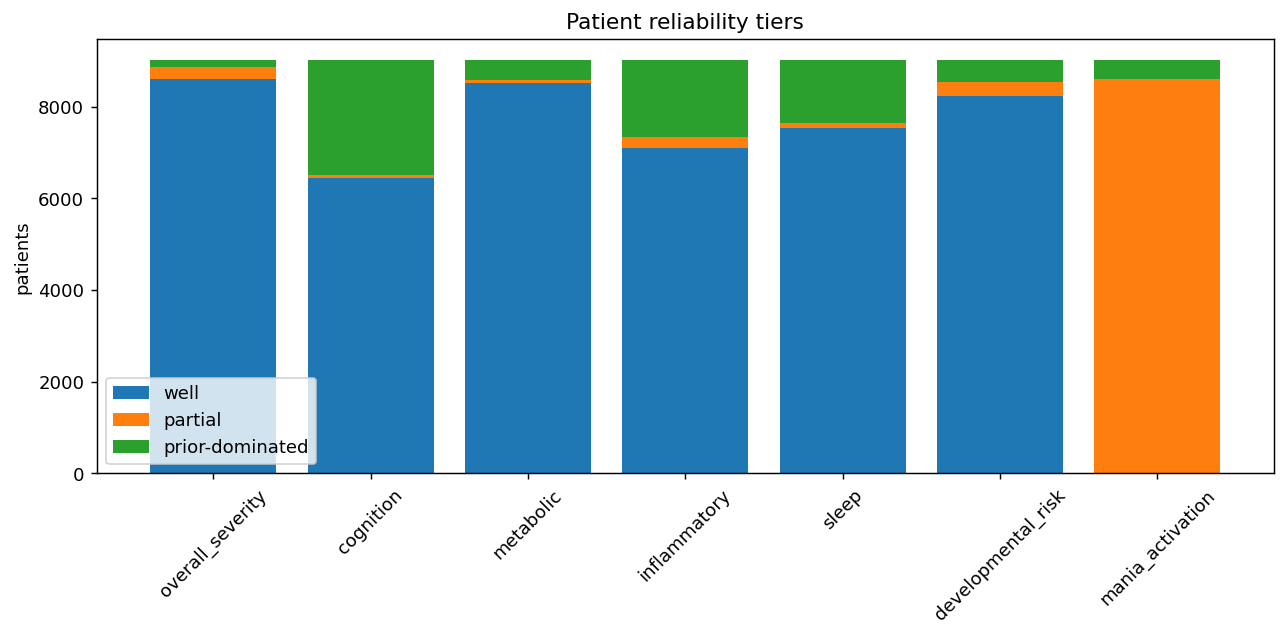

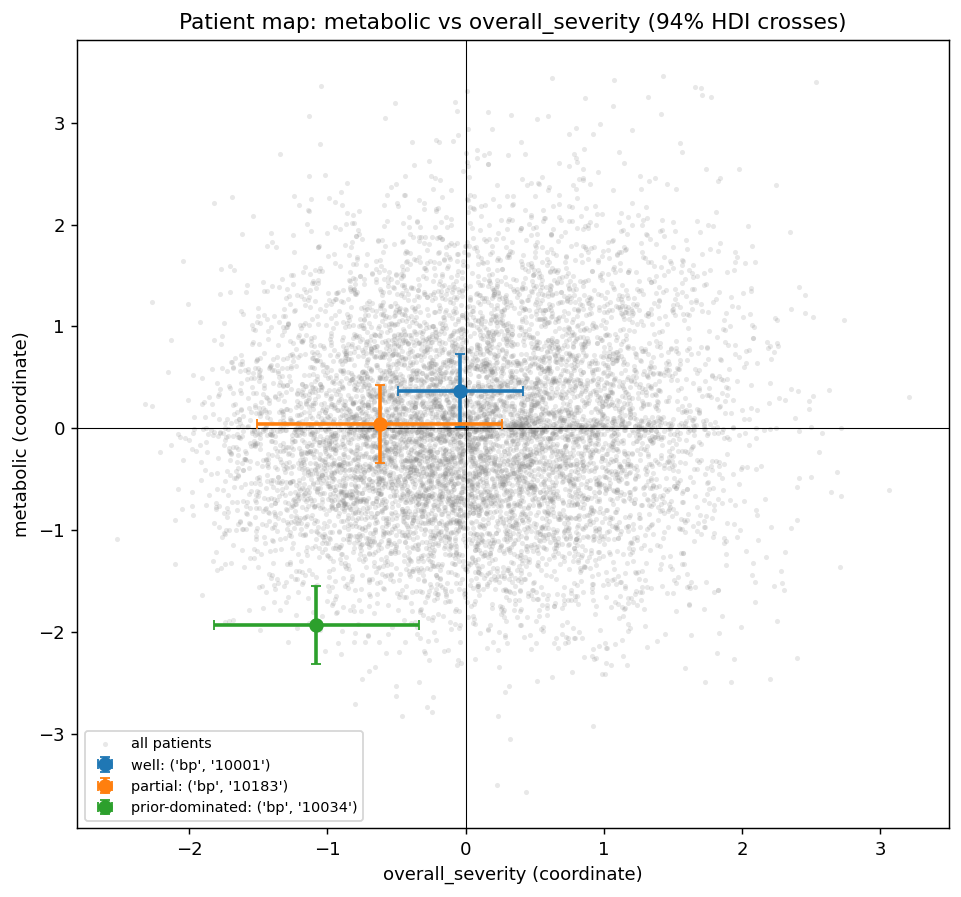

well ('bp', '10001')


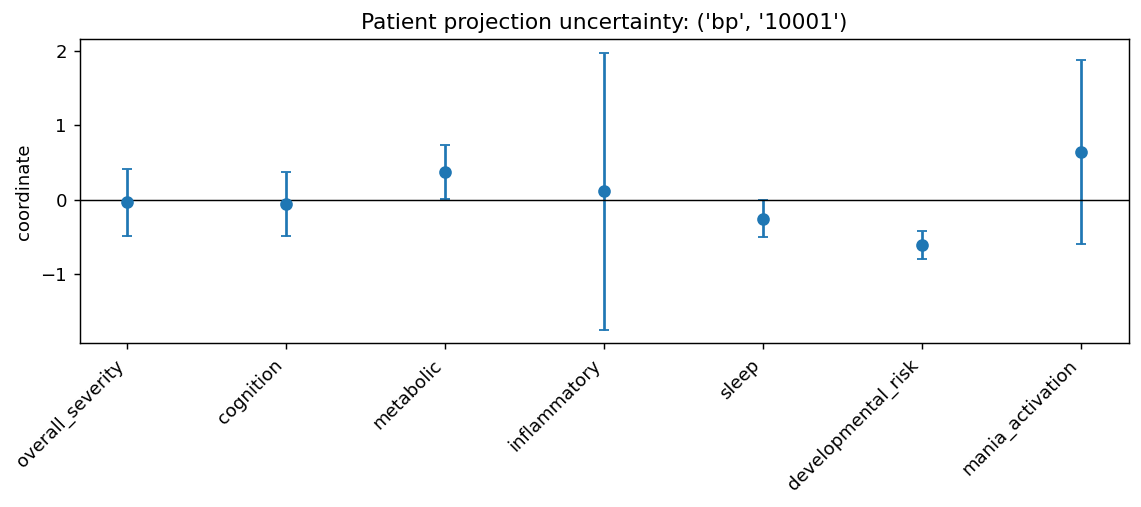

partial ('bp', '10183')


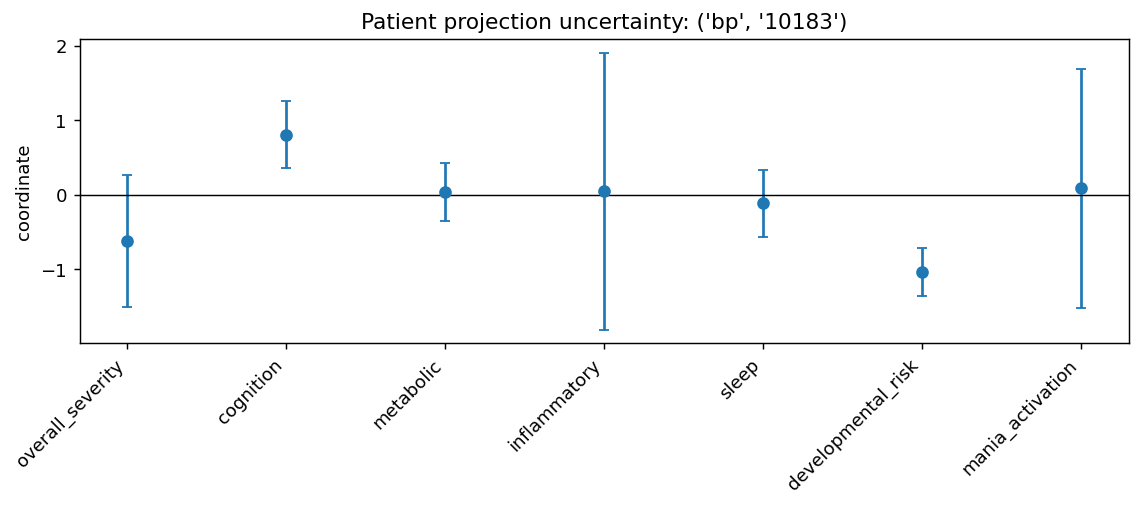

prior-dominated ('bp', '10034')


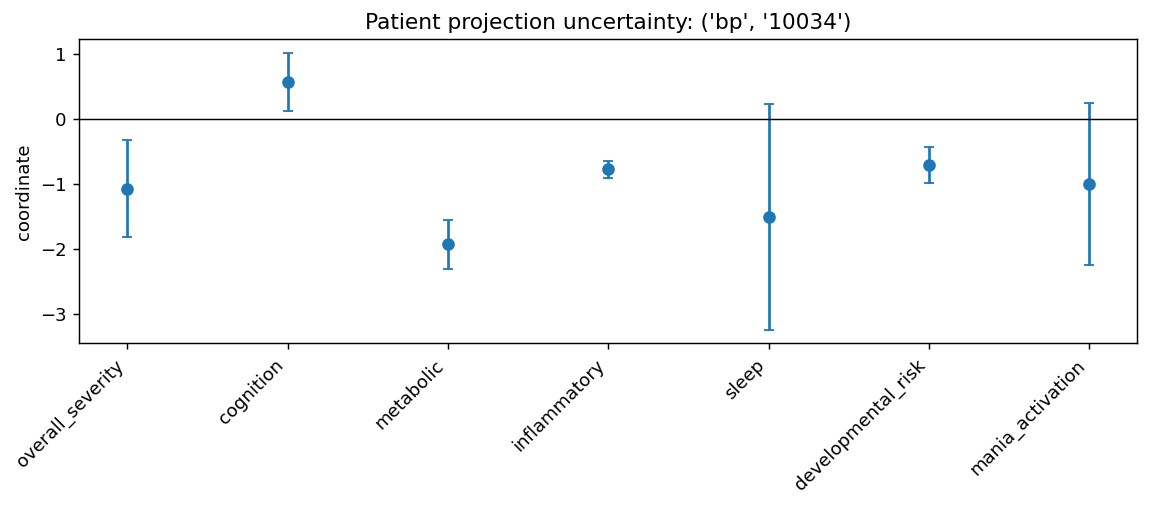

overall_severity__mean overall_severity__reliability  \
cohort patient_id                                                         
bp     10001                    -0.037984                          well   
       10002                    -1.218193                          well   
       10003                    -1.612900                          well   
       10004                    -1.834071                          well   
       10005                    -1.288293                          well   

                   cognition__mean cognition__reliability  metabolic__mean  \
cohort patient_id                                                            
bp     10001             -0.063307                   well         0.369041   
       10002              0.113463                   well         0.262533   
       10003              0.625718                   well        -0.031992   
       10004             -0.962001                   well         0.234335   
       10005              0.391294                   well        -0.386485   

                  metabolic__reliability  inflammatory__mean  \
cohort patient_id                                              
bp     10001                        well            0.109310   
       10002                        well            0.011569   
       10003                        well           -0.089443   
       10004                        well           -0.883968   
       10005                        well            0.663347   

                  inflammatory__reliability  sleep__mean sleep__reliability  \
cohort patient_id                                                             
bp     10001                prior-dominated    -0.254870               well   
       10002                prior-dominated    -1.107816               well   
       10003                prior-dominated    -0.291176               well   
       10004                           well    -0.682227               well   
       10005                           well     0.988723               well   

                   developmental_risk__mean developmental_risk__reliability  \
cohort patient_id                                                             
bp     10001                      -0.607861                            well   
       10002                       0.736755                            well   
       10003                       2.050553                            well   
       10004                      -0.361606                            well   
       10005                      -0.991540                            well   

                   mania_activation__mean mania_activation__reliability  
cohort patient_id                                                        
bp     10001                     0.641243                       partial  
       10002                    -0.077440                       partial  
       10003                    -0.430607                       partial  
       10004                    -0.926226                       partial  
       10005                    -0.246813                       partial

In [6]:
cont_stage = next(s for s in config.stage_plan if s.name == CONT_STAGE)
cont_core = dataset.core(cont_stage.factors, correlated=cont_stage.correlated, windows=cont_stage.windows,
                         balanced=BALANCED, n_subsample=N_SUB, seed=SEED)
projection = projector.projection_frame(cont_core, cont_idata.posterior)

rel_path = visualizer.reliability_bar(projection, cont_core.factor_cols, filename=f"{CONT_STAGE}_reliability.png")
examples, rel_col = {}, "overall_severity__reliability"
for tier in ["well", "partial", "prior-dominated"]:
    m = projection.index[projection[rel_col] == tier]
    if len(m): examples[tier] = m[0]
patient_paths = {t: visualizer.patient_uncertainty(projection, pid, cont_core.factor_cols,
                    filename=f"{CONT_STAGE}_patient_{t}.png") for t, pid in examples.items()}
map_path = visualizer.map_scatter(projection, "overall_severity", "metabolic", highlight=examples,
                                  filename=f"{CONT_STAGE}_map_scatter.png")

display(Image(str(rel_path))); display(Image(str(map_path)))
for t in examples: print(t, examples[t]); display(Image(str(patient_paths[t])))
projection.filter(regex="__(mean|reliability)$").head()

## 6. Synthetic patients

The copula model is invertible, so it doubles as a generator on the original clinical scales:

η ∼ N(0, Φ) → z = Λη + ε → continuous y = F⁻¹(Φ(z)) (copula inversion) · explicit y ∼ fitted GLM.

We load the stored params (`fitted_model/`), generate a synthetic cohort the size of the real one, and check
that it reproduces (a) each indicator's marginal and (b) the dependence structure.

In [7]:
params_dir = config.output_dir / "fitted_model"
if (params_dir / "model.json").exists():
    model = load_fitted_model(params_dir)               # stored by notebooks/run_synthetic_check.py
else:
    model = export_fitted_model(mixed_idata, dataset.mixed(
        mixed_stage.factors, explicit_factors=mixed_stage.explicit_factors,
        min_cohorts=mixed_stage.min_cohorts, n_subsample=None), config, meta={"source": MODE})
    save_fitted_model(model, params_dir)

real = pd.read_parquet(config.processed_dir / "baseline_v0.parquet")
synth = generate_synthetic(model, n=len(real), seed=SEED)
print(f"params: J={model.meta['J']} continuous={len(model.copula)} explicit={model.meta['n_explicit']} | "
      f"synthetic N={len(synth)}")
synth.iloc[:5, :8]

params: J=88 continuous=88 explicit=21 | synthetic N=9013


,agepere,alp_lbstresc,alt_lbstresc,altman,apgr0106_1min,ast_lbstresc,baso_lbstresc,bili_lbstresc
0,39.461838,64.873674,10.505449,4.654410,7.222056,29.845833,0.000000,6.931998
1,26.015879,58.345620,24.194682,1.769235,9.594589,21.787386,0.016030,4.087049
2,33.713572,35.214018,61.609943,4.591384,9.696416,17.653192,0.000327,2.099298
3,22.680347,56.688447,17.171979,0.774200,9.611092,20.940944,0.000000,6.990900
4,31.166455,55.602545,14.138261,5.906668,10.000000,29.940063,0.009860,6.053922


In [8]:
# Marginal fidelity: per-indicator moments, real vs synthetic
import matplotlib.pyplot as plt
rows = []
for it in [c for c in synth.columns if c in real.columns]:
    rv = pd.to_numeric(real[it], errors="coerce").dropna().to_numpy(); sv = synth[it].dropna().to_numpy()
    if rv.size < 20: continue
    rows.append({"item": it, "block": "continuous" if it in model.copula else "explicit",
                 "mean_real": rv.mean(), "mean_synth": sv.mean(), "sd_real": rv.std(), "sd_synth": sv.std()})
moments = pd.DataFrame(rows)
moments["rel_sd_err"] = (moments.sd_real - moments.sd_synth).abs() / moments.sd_real.abs().clip(lower=1e-6)
print("median relative SD error: %.2f%%  (continuous %.2f%% / explicit %.2f%%)" % (
    moments.rel_sd_err.median()*100,
    moments[moments.block=="continuous"].rel_sd_err.median()*100,
    moments[moments.block=="explicit"].rel_sd_err.median()*100))
moments.sort_values("rel_sd_err").head()

median relative SD error: 1.31%  (continuous 0.96% / explicit 1.54%)


,item,block,mean_real,mean_synth,sd_real,sd_synth,rel_sd_err
22,ctq39,continuous,43.769515,43.564870,14.517405,14.519938,0.000174
26,diabpstanding,continuous,76.996135,76.983421,11.988809,11.991178,0.000198
35,fast,continuous,23.223497,23.213796,15.345640,15.350281,0.000302
63,qidsr120,continuous,11.044249,11.026840,6.296651,6.301075,0.000703
61,psqi15,continuous,1.236383,1.262970,0.863999,0.863095,0.001046


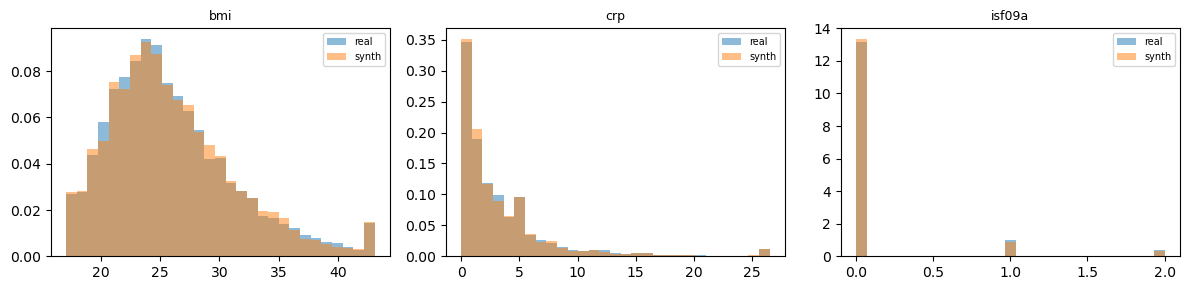

In [9]:
# Overlay a few representative indicators (real vs synthetic)
examples_items = [c for c in ["bmi", "crp", "madrs_total", "isf09a", "suoccur_alcool_lt"] if c in synth.columns and c in real.columns]
if not examples_items:
    examples_items = list(moments.sort_values("rel_sd_err").item.head(4))
fig, axes = plt.subplots(1, len(examples_items), figsize=(4*len(examples_items), 3))
for ax, it in zip(np.atleast_1d(axes), examples_items):
    rv = pd.to_numeric(real[it], errors="coerce").dropna(); sv = synth[it].dropna()
    if rv.nunique() <= 12:
        cats = np.union1d(rv.unique(), sv.unique()); x = np.arange(len(cats))
        ax.bar(x-0.2, rv.value_counts(normalize=True).reindex(cats, fill_value=0), 0.4, label="real")
        ax.bar(x+0.2, sv.value_counts(normalize=True).reindex(cats, fill_value=0), 0.4, label="synth")
    else:
        lo, hi = rv.quantile(.01), rv.quantile(.99); b = np.linspace(lo, hi, 30)
        ax.hist(rv.clip(lo, hi), bins=b, density=True, alpha=.5, label="real")
        ax.hist(sv.clip(lo, hi), bins=b, density=True, alpha=.5, label="synth")
    ax.set_title(it, fontsize=9); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

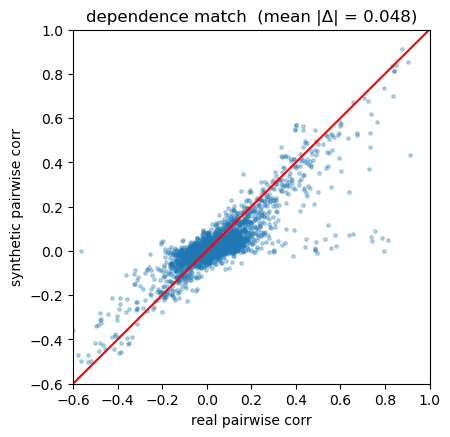

In [10]:
# Dependence fidelity: pairwise correlations on the continuous block, real vs synthetic
cont_items = [it for it in model.items if it in real.columns]
rr, ss = [], []
for i in range(len(cont_items)):
    for j in range(i+1, len(cont_items)):
        a, b = real[cont_items[i]], real[cont_items[j]]; ok = a.notna() & b.notna()
        if ok.sum() < 50: continue
        rr.append(np.corrcoef(a[ok], b[ok])[0, 1]); ss.append(np.corrcoef(synth[cont_items[i]], synth[cont_items[j]])[0, 1])
rr, ss = np.array(rr), np.array(ss)
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.scatter(rr, ss, s=6, alpha=.3); ax.plot([-1, 1], [-1, 1], "r")
ax.set_xlim(-.6, 1); ax.set_ylim(-.6, 1)
ax.set_xlabel("real pairwise corr"); ax.set_ylabel("synthetic pairwise corr")
ax.set_title("dependence match  (mean |Δ| = %.3f)" % np.mean(np.abs(rr - ss)))
plt.show()

## Notes

- **Best result so far:** the full-N (9,013), cohort-weighted, transdiagnostic, sub-1.05 9-dim
  Gaussian-copula map loaded above — most precise (dev↔suic SD halved) and congruent (Tucker φ ≥ 0.994).
- **Substance** is the one weak factor (non-identifiable couplings). The recommended refinement is
  `config.with_substance_orthogonal()` /
  `run_measurement_model_oop.py --likelihood-mode gaussian_copula --cohort-weighted --substance-orthogonal`
  (heavy; overnight). It pins substance as an independent axis without distorting the other factors.
- **Synthetic fidelity:** continuous marginals reproduce to ~1% median SD error (a few ultra-heavy-tailed
  labs are imperfect in the extreme tail), and the dependence structure matches to mean |Δcorr| ≈ 0.05.
- Full reproduction commands: see `REPRODUCE.md`. Batch synthetic report: `notebooks/run_synthetic_check.py`.